In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split



In [3]:
books = pd.read_csv('../data/books_data_2.csv')
books.head()


,kind,title,category,publishDate,publishYear,authorCount,pageCount,maturityRating,saleability,publisher,retailPrice,retailCurrency
0,books#volume,Persuasion,Fiction,2023-03-02,2023,1,276.0,NOT_MATURE,FOR_SALE,neobooks,1.49,GBP
1,books#volume,The Face of Another,Fiction,1992,1992,1,260.0,NOT_MATURE,NOT_FOR_SALE,Kodansha,NaN,NaN
2,books#volume,The Street of Crocodiles,Fiction,2025-03-19T00:00:00Z,2025,1,136.0,NOT_MATURE,NOT_FOR_SALE,Rare Treasure Editions,NaN,NaN
3,books#volume,The Sign of the Four Illustrated,Fiction,2021-05-02,2021,1,156.0,NOT_MATURE,NOT_FOR_SALE,NaN,NaN,NaN
4,books#volume,Generations of Winter,Fiction,1994,1994,1,616.0,NOT_MATURE,NOT_FOR_SALE,Random House (NY),NaN,NaN


In [4]:
books_noduplicates = books.drop_duplicates(subset=["title"])
books_noduplicates.dropna(subset=["saleability"])
books_noduplicates.shape

(5104, 12)

In [5]:
books_noduplicates.info()

<class 'pandas.DataFrame'>
Index: 5104 entries, 0 to 5840
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   kind            5104 non-null   str    
 1   title           5104 non-null   str    
 2   category        5104 non-null   str    
 3   publishDate     5081 non-null   str    
 4   publishYear     5081 non-null   str    
 5   authorCount     5104 non-null   int64  
 6   pageCount       4995 non-null   float64
 7   maturityRating  5104 non-null   str    
 8   saleability     5104 non-null   str    
 9   publisher       3436 non-null   str    
 10  retailPrice     506 non-null    float64
 11  retailCurrency  506 non-null    str    
dtypes: float64(2), int64(1), str(9)
memory usage: 518.4 KB


In [54]:
books_noduplicates.describe(include=['object','category', 'str'])

,kind,title,category,publishDate,publishYear,maturityRating,saleability,publisher,retailCurrency
count,5104,5104,5104,5081,5081,5104,5104,3436,506
unique,1,5104,40,2038,197,2,4,1169,1
top,books#volume,Persuasion,Science,2002,2017,NOT_MATURE,NOT_FOR_SALE,Routledge,GBP
freq,5104,1,159,91,177,5049,4454,124,506


In [55]:
books_noduplicates.describe()

,authorCount,pageCount,retailPrice
count,5104.000000,4995.000000,506.000000
mean,1.267437,333.873073,30.686719
std,0.706060,334.693454,74.203020
min,0.000000,0.000000,0.000000
25%,1.000000,170.500000,6.840000
50%,1.000000,286.000000,14.990000
75%,1.000000,424.000000,35.590000
max,16.000000,7800.000000,1462.750000


In [53]:
books_noduplicates["saleability"].value_counts()

saleability
NOT_FOR_SALE           4454
FOR_SALE                458
FREE                    144
FOR_SALE_AND_RENTAL      48
Name: count, dtype: int64

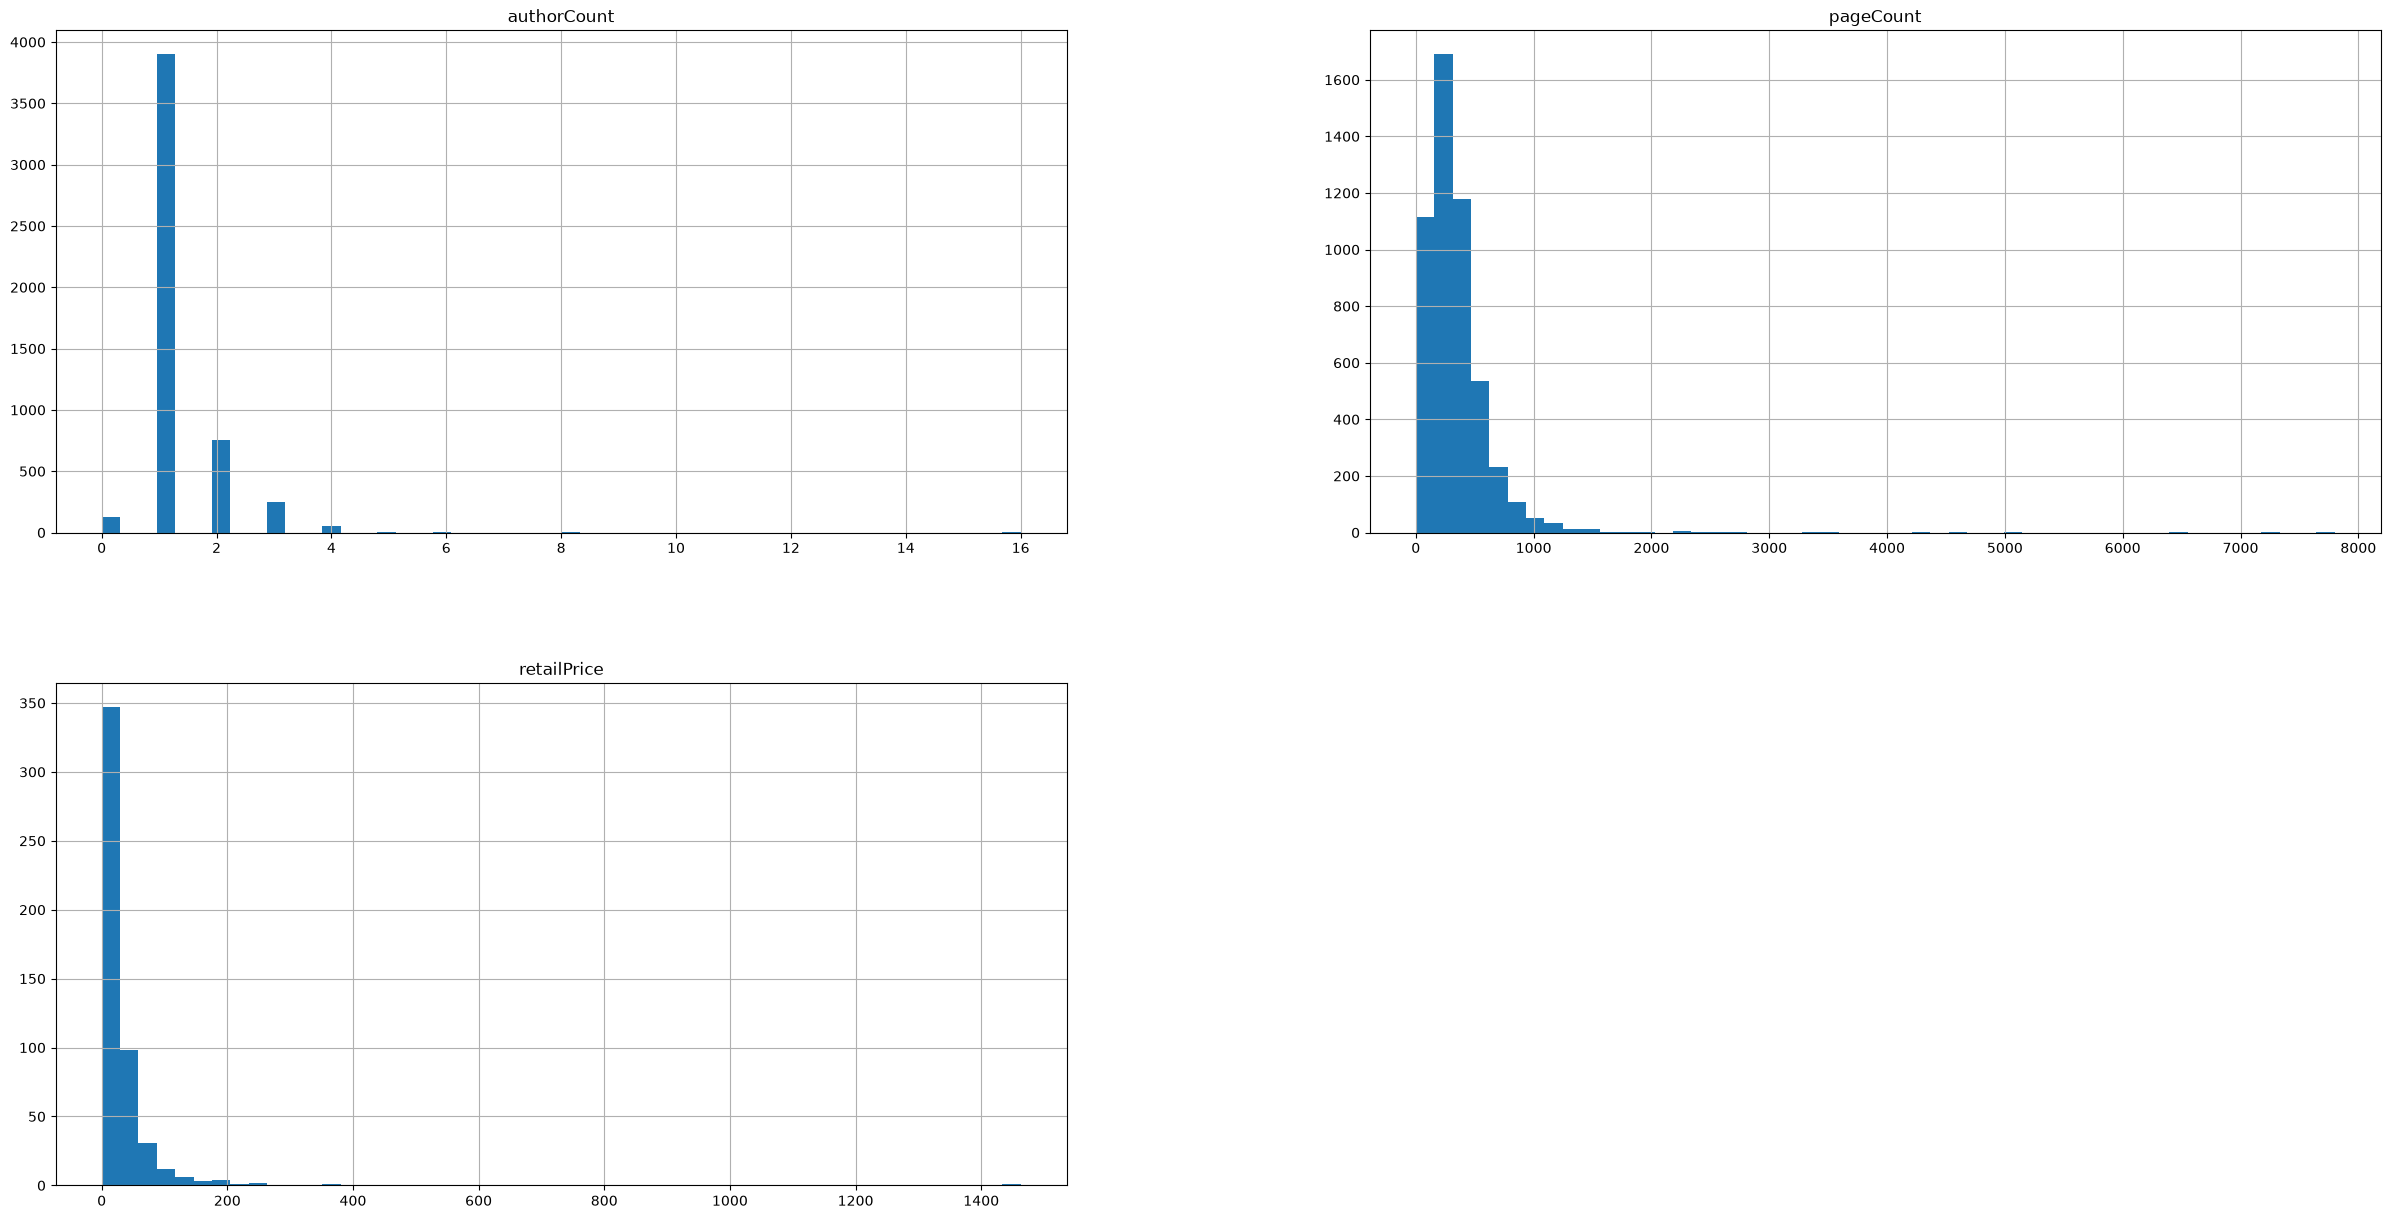

In [24]:


books_noduplicates.hist(bins=50, figsize=(30,15))
plt.savefig("../images/histogram_plots.png")
plt.show()

In [9]:

train_df, test_df = train_test_split(books_noduplicates, test_size=0.2, stratify= books_noduplicates["saleability"], random_state=42)

# 2. Extract features and labels from each split
X_train = train_df.drop(columns=["saleability"])
y_train = train_df["maturityRating"]

X_test = test_df.drop(columns=["saleability"])
y_test = test_df["maturityRating"]

<Axes: xlabel='pageCount', ylabel='retailPrice'>

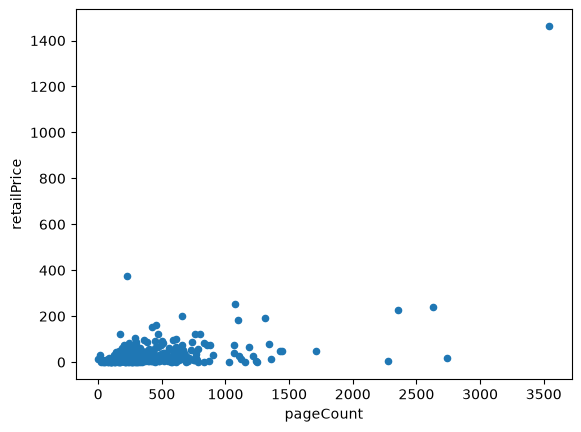

In [10]:
books = train_df.copy()
books.plot(kind = "scatter", x="pageCount", y="retailPrice")



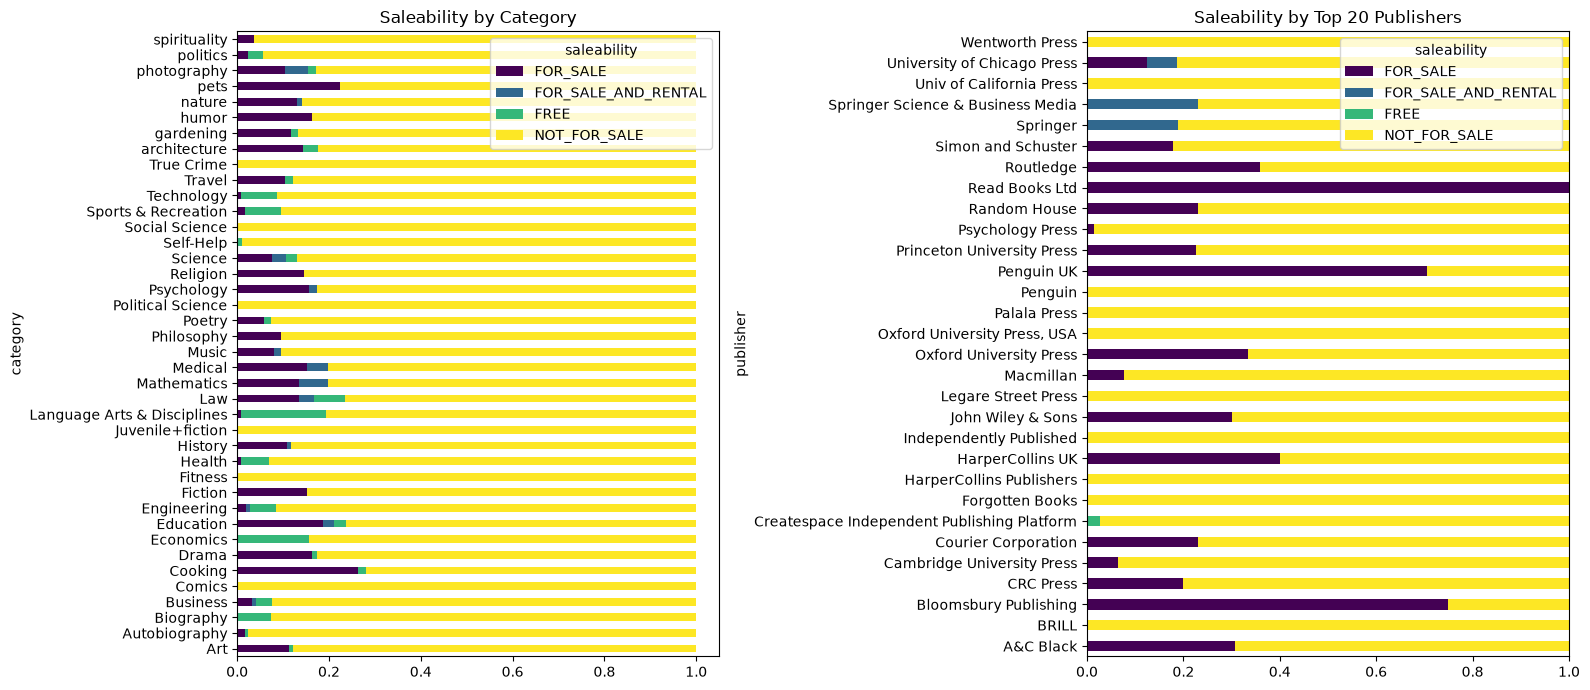

In [ ]:
import seaborn as sns

top_publishers = books["publisher"].value_counts().iloc[:30].index
top_publishers_books = books[books["publisher"].isin(top_publishers)]

fig, axes = plt.subplots(1,2, figsize=(16, 7), sharey=False)
cat_maturity = pd.crosstab(books['category'], books['saleability'], normalize='index')
pub_maturity = pd.crosstab(top_publishers_books["publisher"], top_publishers_books['saleability'], normalize='index')

cat_maturity.plot(kind='barh', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title("Saleability by Category")

pub_maturity.plot(kind='barh', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title("Saleability by Top 20 Publishers")

plt.tight_layout()
plt.show()

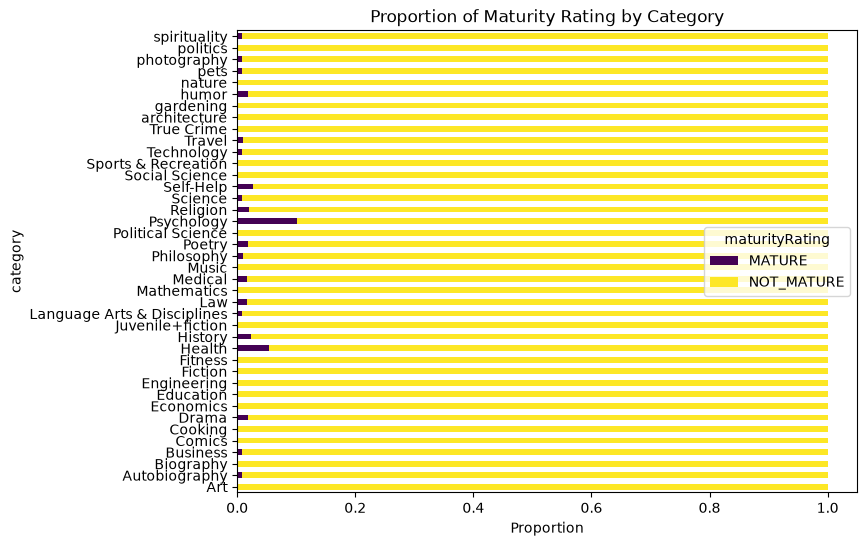

In [ ]:
import seaborn as sns

top_publishers = books["publisher"].value_counts().iloc(:20)


cat_maturity = pd.crosstab(books['category'], books['maturityRating'], normalize='index')

cat_maturity.plot(kind='barh', stacked=True, figsize=(8, 6), colormap='viridis')
plt.title("Proportion of Maturity Rating by Category")
plt.xlabel("Proportion")
plt.show()

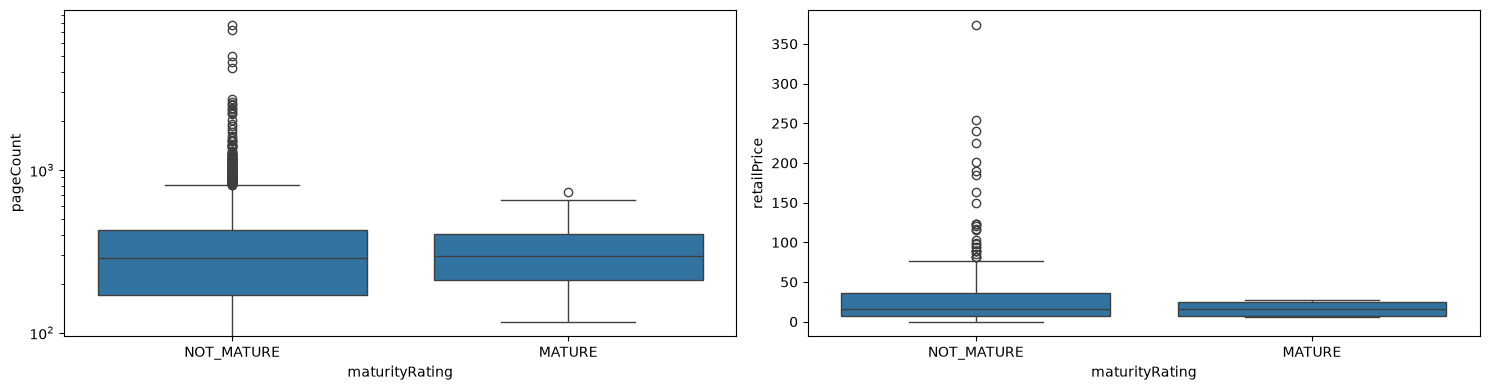

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.boxplot(data=books, x='maturityRating', y='pageCount', ax=axes[0])
sns.boxplot(data=books, x='maturityRating', y='retailPrice', ax=axes[1])

axes[0].set_yscale('log')
plt.tight_layout()
plt.show()

In [11]:
books_copy = train_df.copy()
books_copy.describe(include="all")

,kind,title,category,publishDate,publishYear,authorCount,pageCount,maturityRating,saleability,publisher,retailPrice,retailCurrency
count,4083,4083,4083,4063,4063,4083.000000,4000.000000,4083,4083,2770,405.000000,405
unique,1,4083,40,1705,188,NaN,NaN,2,4,993,NaN,1
top,books#volume,The Law Times,Medical,2002,2018,NaN,NaN,NOT_MATURE,NOT_FOR_SALE,Routledge,NaN,GBP
freq,4083,1,131,77,140,NaN,NaN,4037,3563,103,NaN,405
mean,NaN,NaN,NaN,NaN,NaN,1.267205,335.681250,NaN,NaN,NaN,31.275605,NaN
std,NaN,NaN,NaN,NaN,NaN,0.712023,345.598193,NaN,NaN,NaN,81.105343,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.000000,171.750000,NaN,NaN,NaN,6.990000,NaN
50%,NaN,NaN,NaN,NaN,NaN,1.000000,288.000000,NaN,NaN,NaN,14.990000,NaN
75%,NaN,NaN,NaN,NaN,NaN,1.000000,424.000000,NaN,NaN,NaN,33.190000,NaN


In [13]:
from sklearn.impute import SimpleImputer

cat_imputer = SimpleImputer(strategy="constant", fill_value="Unknown")
num_imputer = SimpleImputer(strategy="median")

books_clean = (
    books_copy
    .drop(columns=["retailPrice", "retailCurrency", "publishDate"])
    .dropna(subset=[ "publishYear"])
)

books_clean.describe(include="all")


,kind,title,category,publishYear,authorCount,pageCount,maturityRating,saleability,publisher
count,4063,4063,4063,4063,4063.000000,3986.000000,4063,4063,2764
unique,1,4063,40,188,NaN,NaN,2,4,989
top,books#volume,The Law Times,Medical,2018,NaN,NaN,NOT_MATURE,NOT_FOR_SALE,Routledge
freq,4063,1,131,140,NaN,NaN,4017,3545,103
mean,NaN,NaN,NaN,NaN,1.269259,335.742599,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,0.711347,345.494295,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,1.000000,172.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,1.000000,288.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,1.000000,424.000000,NaN,NaN,NaN


In [ ]:
books_num = 